# 🔋 Análise Exploratória do Mercado de Veículos Elétricos

Exploração dos dados de registros de veículos elétricos em Washington, cobrindo inspeção inicial da base, estatísticas descritivas e um dashboard com os principais insights de mercado (fabricantes, crescimento, distribuição geográfica e modelos).

## 1. Carregamento e Inspeção Inicial dos Dados

Importação das bibliotecas, leitura da base de dados já tratada e uma primeira visualização das colunas, tipos de dados e estatísticas descritivas para entender a estrutura geral do dataset.

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

df = pd.read_csv('ev_data_limpo.csv')
df.head()


,vin_prefix,county,city,state,postal_code,model_year,make,model,electric_vehicle_type,cafv_eligibility,electric_range,base_msrp,legislative_district,vehicle_id,vehicle_location,electric_utility,census_tract_2020
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [23]:
df.describe()

,postal_code,model_year,electric_range,base_msrp,legislative_district,vehicle_id,census_tract_2020
count,177861.000000,177861.000000,177861.000000,177861.000000,177477.000000,1.778610e+05,1.778610e+05
mean,98172.453506,2020.515667,58.838396,1072.583197,29.127481,2.202312e+08,5.297672e+10
std,2442.450668,2.989206,91.979281,8355.518364,14.892169,7.584774e+07,1.578047e+09
min,1545.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2019.000000,0.000000,0.000000,18.000000,1.814762e+08,5.303301e+10
50%,98122.000000,2022.000000,0.000000,0.000000,33.000000,2.282526e+08,5.303303e+10
75%,98370.000000,2023.000000,75.000000,0.000000,42.000000,2.548448e+08,5.305307e+10
max,99577.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


## 📊 Mercado de Veículos Elétricos

Análise exploratória dos registros de veículos elétricos em Washington, destacando os principais fabricantes, a evolução das matrículas ao longo dos anos, a distribuição geográfica por condado e os modelos mais vendidos no mercado.

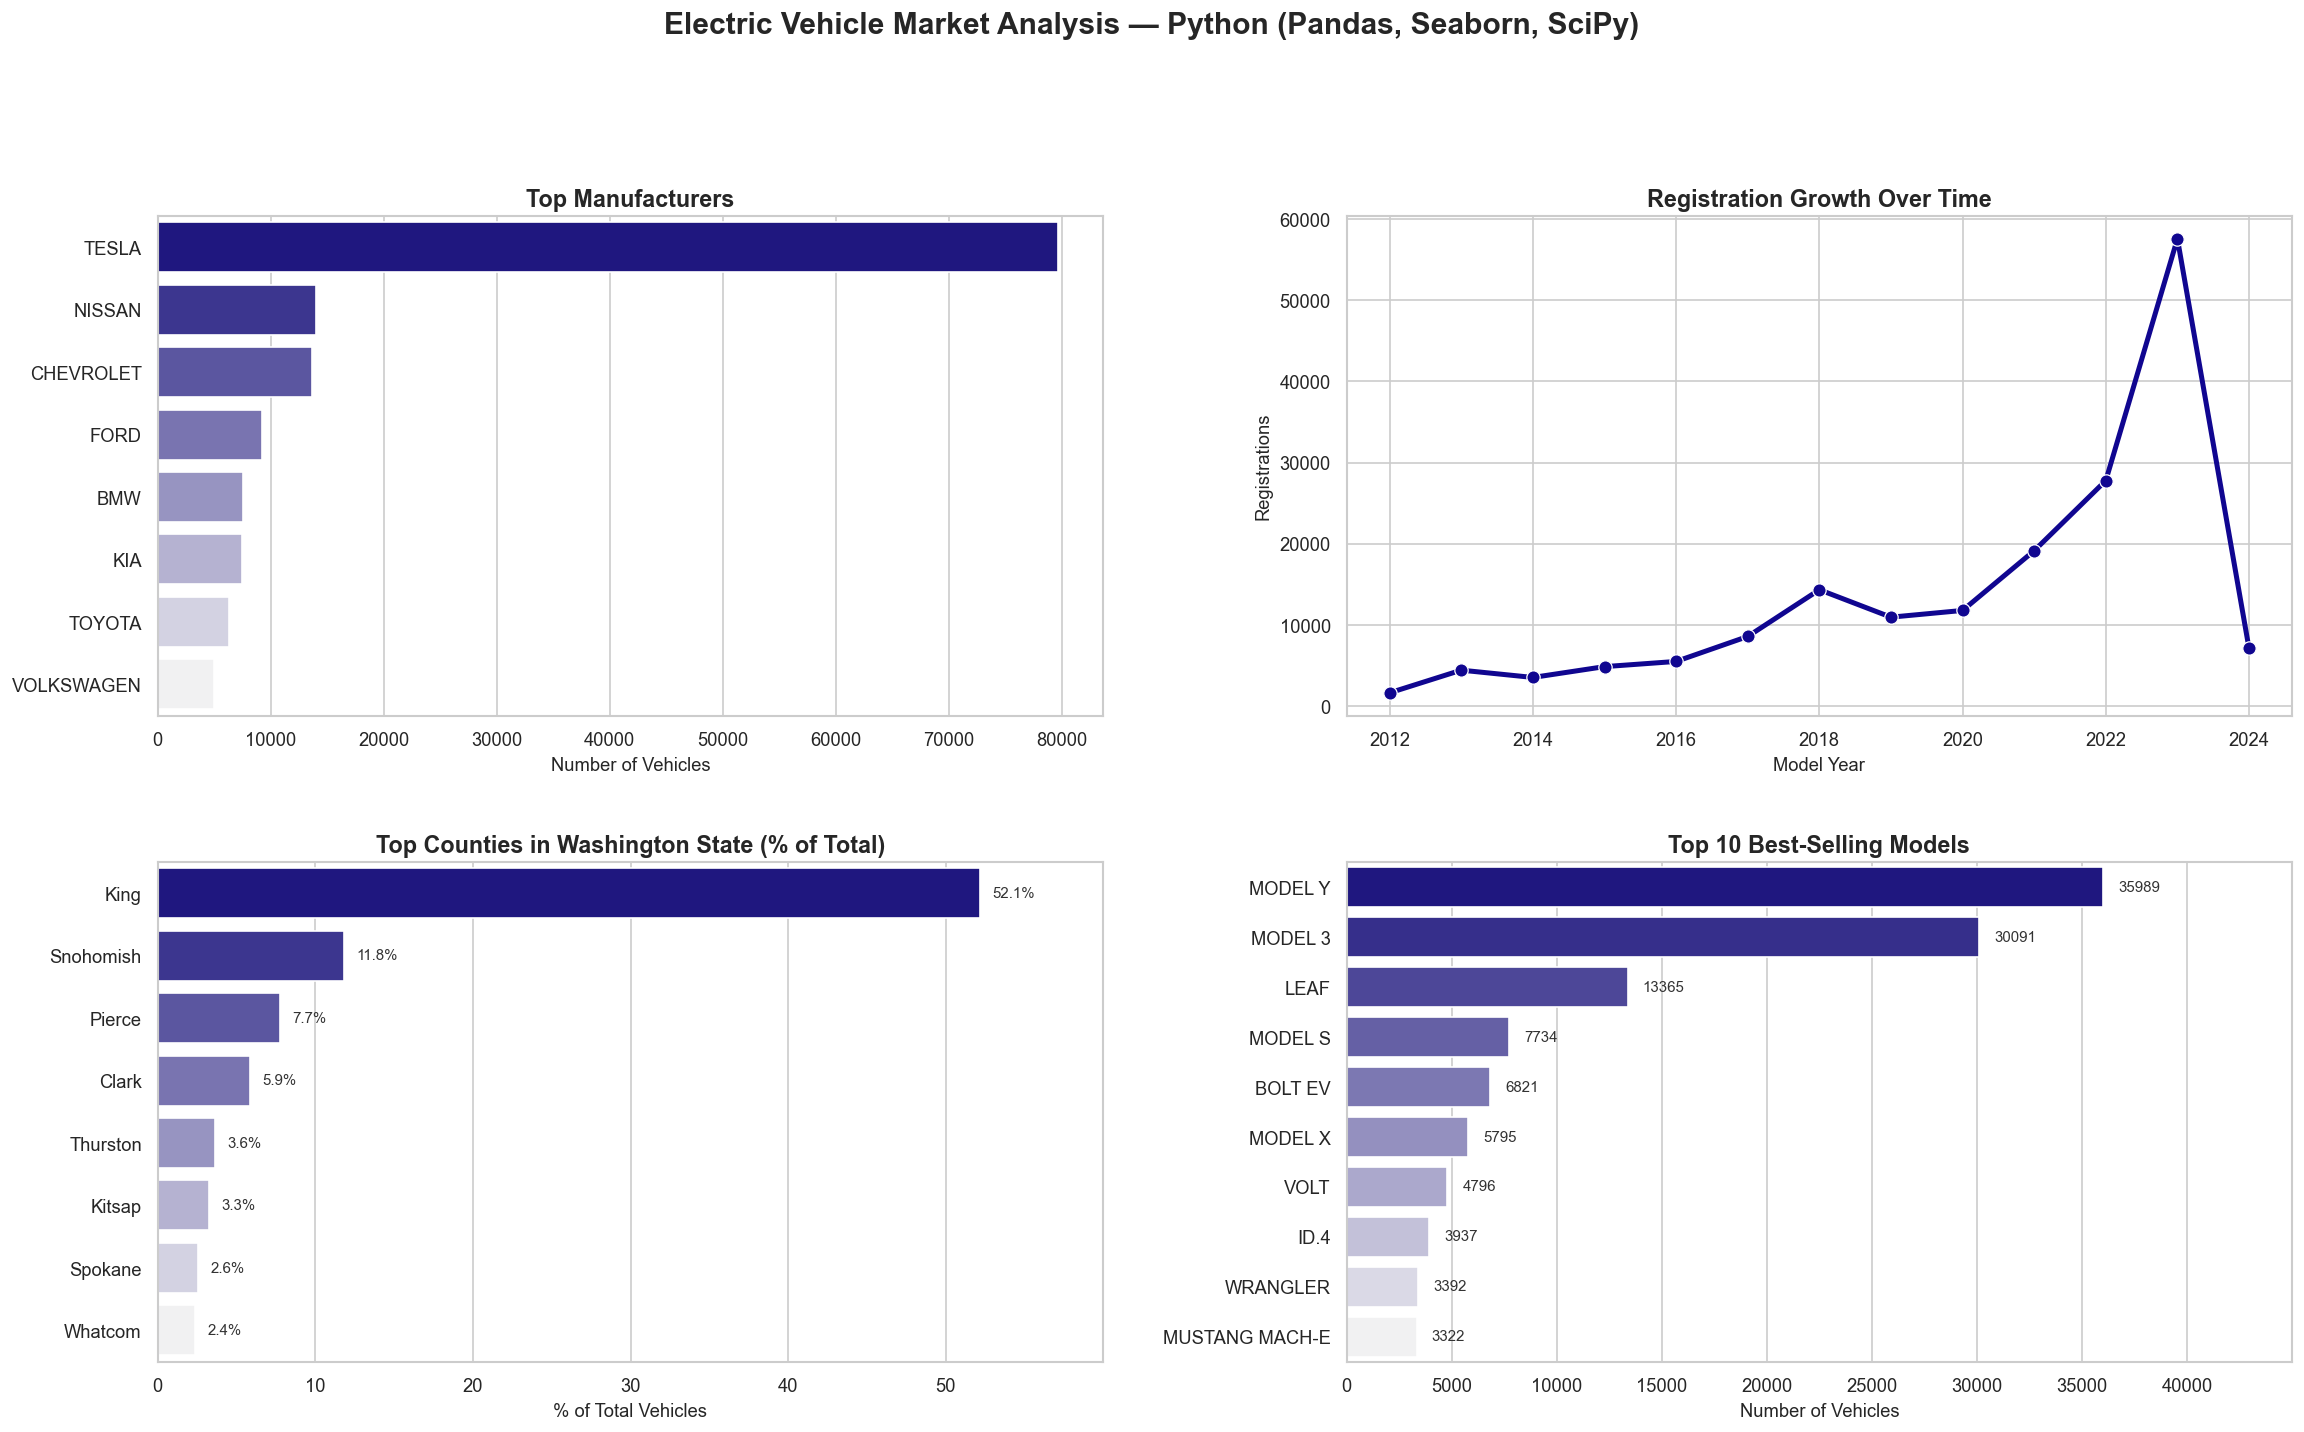

In [44]:

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
df = pd.read_csv('ev_data_limpo.csv')

def blues(n, reverse=True):
    return sns.light_palette("#100690", n_colors=n, reverse=reverse)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Electric Vehicle Market Analysis — Python (Pandas, Seaborn, SciPy)',
             fontsize=18, fontweight='bold', y=1.02)

# Painel 1 — Top fabricantes
top10 = df['make'].value_counts().head(8)
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, palette=blues(len(top10)),
            legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Top Manufacturers", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Number of Vehicles", fontsize=11)
axes[0, 0].set_ylabel("")

# Painel 2 — Evolução por ano
yearly = df[df['model_year'] >= 2012].groupby('model_year').size()
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', linewidth=3,
             markersize=8, color='#100690', ax=axes[0, 1])
axes[0, 1].set_title("Registration Growth Over Time", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Model Year", fontsize=11)
axes[0, 1].set_ylabel("Registrations", fontsize=11)

# Painel 3 — Top condados dentro de WA, como % do total (não contagem bruta)
top_counties_pct = (df['county'].value_counts(normalize=True) * 100).head(8)
sns.barplot(x=top_counties_pct.values, y=top_counties_pct.index, hue=top_counties_pct.index,
            palette=blues(len(top_counties_pct)), legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Top Counties in Washington State (% of Total)", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("% of Total Vehicles", fontsize=11)
axes[1, 0].set_ylabel("")
axes[1, 0].set_xlim(0, top_counties_pct.max() * 1.15)

# anota o valor percentual exato ao lado de cada barra
for i, v in enumerate(top_counties_pct.values):
    axes[1, 0].text(v + top_counties_pct.max() * 0.015, i, f"{v:.1f}%",
                     va='center', fontsize=9, color='#333333')

# Painel 4 — Top modelos gerais
top_models = df['model'].value_counts().head(10).reset_index()
top_models.columns = ['model', 'count']
top_models = top_models.sort_values('count', ascending=False)

sns.barplot(data=top_models, x='count', y='model', hue='model',
            palette=blues(len(top_models)), legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Top 10 Best-Selling Models", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Number of Vehicles", fontsize=11)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlim(0, top_models['count'].max() * 1.25)

for i, (_, row) in enumerate(top_models.iterrows()):
    axes[1, 1].text(row['count'] + top_models['count'].max() * 0.02, i,
                     str(row['count']), va='center', fontsize=9, color='#333333')

plt.tight_layout(pad=3.0)
plt.savefig('dashboard_final_slide.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()